In [6]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
n_samples = 250

In [ ]:
# Вариант 4 Касьянова Кристина Александровна
X = np.random.rand(n_samples, 2)
Y = (((5*X[:, 0]-0.9))+(-4*X[:, 1]-0.1) > 0.5)

In [8]:

def step_function(x):   # определим пороговую функцию активации
    return np.where(x >= 0, 1, 0)

def perceptron_predict(X, weights, bias): # прогнозирование класса с использованием перцептрона
    return step_function(np.dot(X, weights) + bias)

def perceptron_train(X, Y, learning_rate=0.1, epochs=1000): # обучение перцептрона
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)  # веса сделаем нулями
    bias = 0  # смещение

    for _ in range(epochs):
        for i in range(n_samples):
            prediction = perceptron_predict(X[i], weights, bias)
            # Обновляем веса и смещение с использованием метода градиентного спуска
            weights += learning_rate * (Y[i] - prediction) * X[i]
            bias += learning_rate * (Y[i] - prediction)

    return weights, bias

weights, bias = perceptron_train(X, Y)    
# обучение перцептрона

Будем использовать обученные весовые коэффициенты и смещение для построения графика разделяющей прямой и отображения точек данных

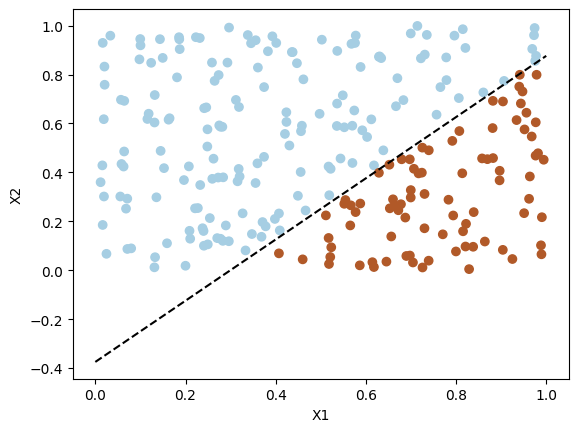

Weights: [ 1.33571872 -1.06764238]
Bias: -0.4


In [9]:
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired) # график, разделяющий классы
plt.xlabel('X1')
plt.ylabel('X2')

x_vals = np.linspace(0, 1, 100) # вычисление координат прямой, разделяющей классы
y_vals = (-weights[0] * x_vals - bias) / weights[1]


plt.plot(x_vals, y_vals, 'k--') # построение прямой

plt.show() #график

print("Weights:", weights) # весовые коэффициенты и смещение
print("Bias:", bias)

Проанализиируем как различные различные начальные весовые коэффициенты и смещения влияют на результаты классификации (число точек уменьшим).
Изменим начальные приближения перед обучением перцептрона. Введем некоторые случайные начальные веса и смещение и проанализируем, как это повлияет на результат.

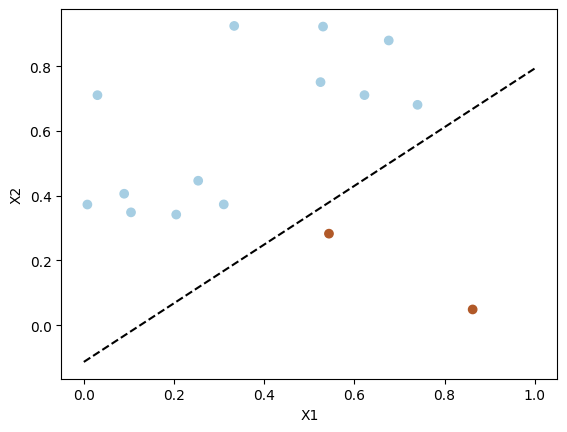

Weights: [ 0.18275248 -0.20169078]
Bias: -0.022859755979658142


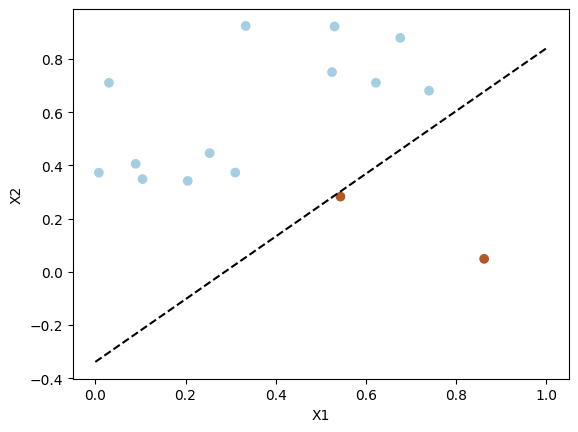

Weights: [ 0.36443889 -0.3092694 ]
Bias: -0.10472999409531392


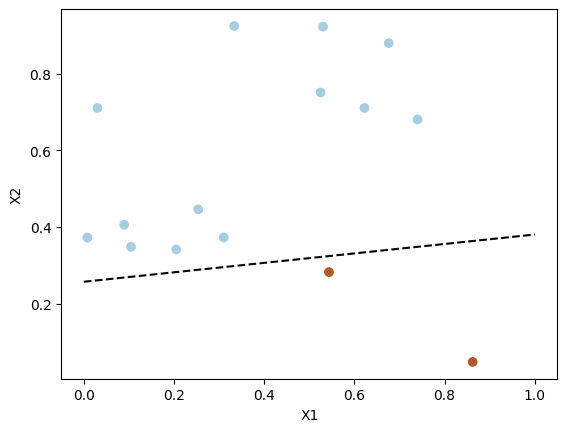

Weights: [ 0.03437156 -0.27935195]
Bias: 0.07195714059582242


In [10]:

n_samples = 15 # число точек

X = np.random.rand(n_samples, 2) # генерирование случайных точек в двумерном пространстве

Y = (((5*X[:, 0]-0.9) + (-4*X[:, 1]-0.1)) > 0.5).astype(int) # создание меток классов с помощью заданного условия

def step_function(x):   # определение пороговой функции активации
    return np.where(x >= 0, 1, 0)

def perceptron_predict(X, weights, bias):  # прогнозирование класса с использованием перцептрона
    return step_function(np.dot(X, weights) + bias)

def perceptron_train(X, Y, learning_rate=0.1, epochs=1000, init_weights=None, init_bias=None): # обучение перцептрона
    n_samples, n_features = X.shape
    if init_weights is None:
        weights = np.zeros(n_features)  # веса 
    else:
        weights = init_weights
    if init_bias is None:
        bias = 0  # смещение
    else:
        bias = init_bias

    for _ in range(epochs):
        for i in range(n_samples):
            prediction = perceptron_predict(X[i], weights, bias)
            weights += learning_rate * (Y[i] - prediction) * X[i]  # градиентный спуск
            bias += learning_rate * (Y[i] - prediction)

    return weights, bias

# Используем различные начальные веса и смещения
init_weights_list = [np.random.rand(2), np.random.rand(2), np.random.rand(2)]
init_bias_list = [np.random.rand(), np.random.rand(), np.random.rand()]

# Обучаем перцептрон с различными начальными весами и смещениями
for init_weights, init_bias in zip(init_weights_list, init_bias_list):
    weights, bias = perceptron_train(X, Y, init_weights=init_weights, init_bias=init_bias)

    plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)  # построение графика, разделяющего классы
    plt.xlabel('X1')
    plt.ylabel('X2')

    x_vals = np.linspace(0, 1, 100)  # вычисление координат прямой, разделяющей классы
    y_vals = (-weights[0] * x_vals - bias) / weights[1]

    plt.plot(x_vals, y_vals, 'k--')     # построение прямой, разделяющей классы

    plt.show()     # график

    print("Weights:", weights) #весовые коэффициенты и смещение
    print("Bias:", bias)


### Результаты 

Провели бинарную классификацию с использованием простейшего перцептрона с пороговой функцией активации. Сгенерировали случайные точки в двумерном пространстве для двух классов, после чего обучили перцептрон на этом наборе данных с использованием метода градиентного спуска. Построили разделяющую прямую, разделяющую два класса, с использованием обученных весовых коэффициентов и смещения.

График демонстрирует результаты классификации, где каждая точка на графике представляет собой один из двух классов, а разделяющая прямая определяет границу между этими классами. Также выведены весовые коэффициенты и смещение были выведены, для того, чтобы мы могли увидеть как именно была построена разделяющая прямая. 
